[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aledamelio/ML_Pavia/blob/main/02_Linear_Classifiers.ipynb)

# Linear Classifiers

## The McCulloch-Pitts Artificial Neuron

- Proposed by Warren McCulloch and Walter Pitts in 1943 (*A Logical Calculus of the Ideas Immanent in Nervous Activity*, W. S. McCulloch & W. Pitts, *Bulletin of Mathematical Biophysics*, 5(4): 115–133, 1943).
- It represents the earliest computational model designed to simulate the basic mechanics of a biological neuron.

<img src="images/02_01.png" width="750">

- **Logic Gate Behavior:** Functions as a binary logic gate, outputting either $-1$ (not firing) or $1$ (firing).
- **Signal Integration:** Multiple input signals arrive through the dendrites and accumulate within the cell body (soma).
- **Threshold Activation:** If the aggregated input exceeds a predefined threshold, the neuron "fires," transmitting an output signal down the axon.


## Formal Definition of an Artificial Neuron

- **Input Vector:** We define the neuron's input as an $m$-dimensional vector:

$$\mathbf{x}=\left[\begin{array}{c}
x_{1} \\
\vdots \\
x_{m}
\end{array}\right]$$

- **Synaptic Weights:** Signal integration scales each input $x_i$ by a corresponding weight $w_i$, collected into a weight vector:

$$\mathbf{w}=\left[\begin{array}{c}
w_{1} \\
\vdots \\
w_{m}
\end{array}\right]$$

- **Net Input Signal:** The accumulated signal $z$ is computed as the linear combination (dot product) of $\mathbf{x}$ and $\mathbf{w}$:

$$z = w_{1} x_{1}+\dots+w_{m} x_{m}=\mathbf{w}^{T} \mathbf{x}$$

- **Thresholding & Activation:** If $z$ reaches or exceeds a threshold $c$, the neuron outputs a positive signal; otherwise, it outputs a negative signal. This behavior is modeled by the activation function $\phi(z)$:

$$\phi(z)=\left\{\begin{aligned}
1 & \text{ if } z \geq c \\
-1 & \text{ otherwise}
\end{aligned}\right.$$

The artificial neuron defines a decision boundary (a separating hyperplane) that divides the input space into distinct regions:

- The *"Firing Region:"* $\left\{\mathbf{x} \in \mathbb{R}^{m}: \mathbf{w}^{\top} \mathbf{x}>c\right\}$

- The *"Not Firing Region:"* $\left\{\mathbf{x} \in \mathbb{R}^{m}: \mathbf{w}^{\top} \mathbf{x} \leq c\right\}$

In general, a separating hyperplane is defined as:

$$\left\{\mathbf{x} \in \mathbb{R}^{m}: \mathbf{w}^{\top} \mathbf{x}=c\right\}$$


#### Homogeneous Hyperplanes

If $c=0$, the hyperplane passes through the origin (a homogeneous hyperplane).

- Every hyperplane can be rendered as a homogeneous hyperplane: the threshold $c$ can be absorbed directly into the linear combination by introducing a bias weight $w_0 = -c$ and an extra input parameter $x_0 = 1$:

$$z = w_{0} x_{0} + w_{1} x_{1} + \dots + w_{m} x_{m} = \mathbf{w}^{T} \mathbf{x}$$

- With the bias incorporated, the activation function simplifies to:

$$\phi(z)=\left\{\begin{aligned}
1 & \text{ if } z \geq 0 \\
-1 & \text{ otherwise}
\end{aligned}\right.$$

**Example:** given $m = 2$ and $c=0$, consider the line defined by the following weight vector:

$$\mathbf{w}=\left[\begin{array}{r}
1 \\
-1
\end{array}\right]$$

For a arbitrary vector $\mathbf{x}=\left[\begin{array}{c}
x_{1} \\
x_{2}
\end{array}\right]$, the line passes through the origin:

$$\mathbf{w}^{T} \mathbf{x} = 0$$
$$1x_1 - 1x_2 = 0$$
$$x_1 = x_2$$

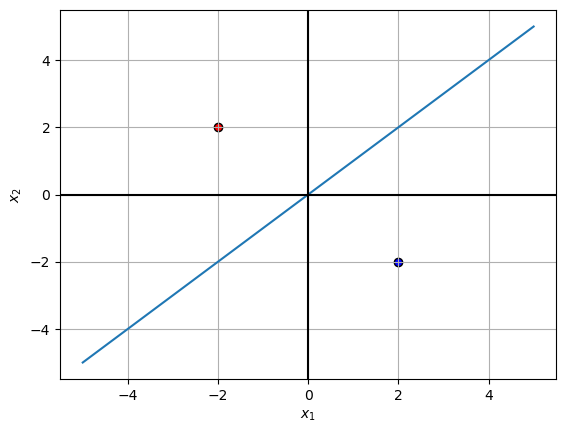

In [37]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(-5,5,100)
x2 = np.linspace(-5,5,100)
plt.plot(x1,x2)
plt.axvline(0.0, color='k')
plt.axhline(0.0, color='k')
plt.scatter(-2,2, color='r', edgecolor='k')
plt.scatter(2,-2, color='b', edgecolor='k')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid()
plt.show()

This lines divedes the space in two subregions:

* Suppose $\mathbf{x} = \begin{bmatrix} -2 \\ 2 \end{bmatrix}$, then $\mathbf{w}^{\top} \mathbf{x} = -4 < 0$

* Suppose $\mathbf{x} = \begin{bmatrix} 2 \\ -2 \end{bmatrix}$, then $\mathbf{w}^{\top} \mathbf{x} = 4 > 0$

In [38]:
w = np.array([1,-1])
x1 = np.array([-2,2])
x2 = np.array([2,-2])
z1 = np.dot(w.T,x1)
z2 = np.dot(w.T,x2)

print(z1, z2)

-4 4


We apply the activation function:

$$\phi(z)=\left\{\begin{aligned}
1 & \text { if } z \geq 0 \\
-1 & \text { otherwise }
\end{aligned}\right.$$

In [39]:
def phi(z):
    return np.where(z >= 0, 1, -1)

print(phi(z1))
print(phi(z2))

-1
1


The activation function defined this way is commonly known as the **sign function** $\operatorname{sgn}(z)$. Note that:

$$\phi(z) = \operatorname{sgn}(z) = \operatorname{sgn}(\mathbf{w}^{T} \mathbf{x}) = \operatorname{sgn}(\|\mathbf{w}\| \|\mathbf{x}\| \cos\theta) = \operatorname{sgn}(\cos\theta)$$

where $\theta$ is the angle between the vectors $\mathbf{w}$ and $\mathbf{x}$.

Thus, the sign of $\mathbf{w}^{T} \mathbf{x}$ depends exclusively on $\theta$. As a result, rotating either vector by $180^\circ$ (which reverses its sign) will also flip the sign of $\operatorname{sgn}(\mathbf{w}^{T} \mathbf{x})$.

In [40]:
w = np.array([1,-1]) * (-1)
x1 = np.array([-2,2])
x2 = np.array([2,-2])
z1 = np.dot(w.T,x1)
z2 = np.dot(w.T,x2)

print(z1, z2)
print(phi(z1))
print(phi(z2))

4 -4
1
-1


Inverting the sign of the weight vector $\mathbf{w}$ reverses the neuron's output. However, the decision boundary defined by the separating hyperplane $\mathbf{w}^{T} \mathbf{x} = 0$ remains unchanged.

### The Artificial Neuron as a Classification Model

- An artificial neuron can serve as a binary classification model.
- We denote the two target classes as $+1$ (the positive class) and $-1$ (the negative class).
- The input signal is represented by the feature vector:


<img src="images/02_02.png" width="500">

## Learning $\boldsymbol{w}$: The Perceptron Algorithm

- Proposed by Frank Rosenblatt in 1957.
- An iterative algorithm to learn the optimal weight vector $\mathbf{w}$ of an artificial neuron directly from data: $(\mathbf{X}, \mathbf{y})$. 

**Algorithm Steps:**

1. **Initialization:** Set the weight vector $\mathbf{w}$ to small random values (or zeros).

2. **Iterative Update:** For each training example $\mathbf{x}^{(i)}$:
   
   a. **Compute Prediction:** $\hat{y}^{(i)} = \phi\left(\mathbf{w}^{T} \mathbf{x}^{(i)}\right)$
   
   b. **Update Weights:** Adjust $\mathbf{w}$ based on the prediction error.


<img src="images/02_04.png" width="600">

Let $\mathbf{w}$ be the weight vector and $w_j$ its $j$-th element. We define the weight update rule as:

$$w_{j} := w_{j} + \Delta w_{j}$$

where $\Delta w_{j}$ represents the weight adjustment applied to $w_{j}$, defined by:

$$\Delta w_{j} = \eta\left(y^{(i)} - \hat{y}^{(i)}\right) x_{j}^{(i)}$$

This update is applied simultaneously across all dimensions $j$. For instance, in a 2D dataset ($m=2$):

$$\begin{aligned}
\Delta w_{0} &= \eta\left(y^{(i)} - \phi(\mathbf{w}^{T} \mathbf{x}^{(i)})\right) x_{0}^{(i)} \quad \text{where } x_{0}^{(i)} = 1 \\
\Delta w_{1} &= \eta\left(y^{(i)} - \phi(\mathbf{w}^{T} \mathbf{x}^{(i)})\right) x_{1}^{(i)} \\
\Delta w_{2} &= \eta\left(y^{(i)} - \phi(\mathbf{w}^{T} \mathbf{x}^{(i)})\right) x_{2}^{(i)}
\end{aligned}$$

In vector notation:

$$\Delta \mathbf{w} = \eta\left(y^{(i)} - \phi(\mathbf{w}^{T} \mathbf{x}^{(i)})\right) \mathbf{x}^{(i)}$$
$$\mathbf{w} := \mathbf{w} + \Delta \mathbf{w}$$

#### What Does This Update Rule Tell Us?

- **Correct Classification:** If the Perceptron predicts the class correctly, no updates are made:

$$\begin{aligned}
y^{(i)} = -1, \quad \hat{y}^{(i)} = -1 \implies \Delta w_{j} &= \eta(-1 - (-1)) x_{j}^{(i)} = 0 \\
y^{(i)} = 1, \quad \hat{y}^{(i)} = 1 \implies \Delta w_{j} &= \eta(1 - 1) x_{j}^{(i)} = 0
\end{aligned}$$

- **Misclassification:** If the Perceptron predicts the class incorrectly, the weights are adjusted based on the direction of the error:

$$\begin{aligned}
y^{(i)} = 1, \quad \hat{y}^{(i)} = -1 \implies \Delta w_{j} &= \eta(1 - (-1)) x_{j}^{(i)} = 2\eta x_{j}^{(i)} \\
y^{(i)} = -1, \quad \hat{y}^{(i)} = 1 \implies \Delta w_{j} &= \eta(-1 - 1) x_{j}^{(i)} = -2\eta x_{j}^{(i)}
\end{aligned}$$

**Example:**

Consider the following parameter values:
- $\eta = 1$
- $x_{j}^{(i)} = 0.5$
- $\hat{y}^{(i)} = -1$
- $y^{(i)} = 1$

The weight change is calculated as:

$$\Delta w_{j} = (1 - (-1)) \cdot 0.5 = (2) \cdot 0.5 = 1$$

In this case, the weight $w_{j}$ is increased ("made more positive"), steering the linear combination to favor a $+1$ output on subsequent passes.

In general, the update rule adjusts $w_j$ such that the term $w_j x_j$ shifts in the direction of the true label $y^{(i)}$.

*Note:* The magnitude of the weight adjustment is directly proportional to the magnitude of the input feature $x_{j}^{(i)}$.

#### Algorithm Convergence

The Perceptron learning algorithm repeatedly applies the update rule $w_{j} := w_{j} + \Delta w_{j}$ (for each dimension $j$) across the entire dataset for $K$ iterations.

- $K$ is referred to as the **number of epochs** (full passes over the dataset).

**How to set $K$?**

- $K$ is a **hyperparameter**. In practice, it is chosen to be large enough to allow the algorithm to converge.
- Convergence is mathematically guaranteed if the dataset is **linearly separable** (Novikoff's Perceptron Convergence Theorem).

<img src="images/02_03.png" width="600">


<br>
<br>

# Implement the Perceptron in Python

In [76]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)


class Perceptron():
  
    def __init__(self, eta=0.001, n_iter=50, random_state=123):
        self.eta = eta
        self.n_iter = n_iter
        np.random.seed(random_state)
        
    def fit(self, X, y):
       
        self.w_ = np.random.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for it in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def activation_function(self, Z):
        return np.where(Z >= 0.0, 1, -1)
        
    def predict(self, X):
        return self.activation_function(np.dot(X, self.w_[1:]) + self.w_[0])
    

## Learning the Perceptron on the Iris dataset

### Loading the Iris dataset

In [77]:
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('URL:', s)

df = pd.read_csv(s, header=None, names=['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width', 'Species'])

df.tail()

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


<hr>

### Let's have a look at the dataset

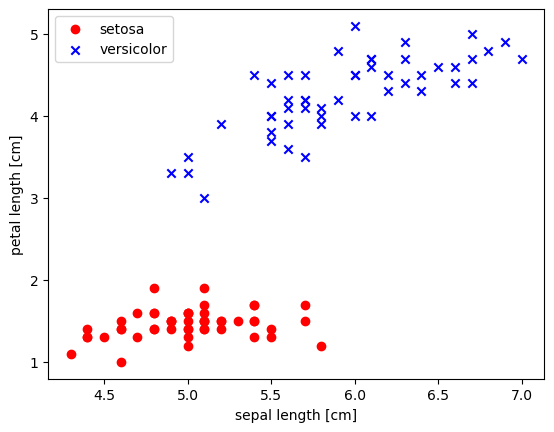

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# select setosa and versicolor
y = df.iloc[0:100, 4].values
y_iris = np.where(y == 'Iris-setosa', -1, 1)
#y_iris = np.where(y == 'Iris-setosa', 1, -1)

# extract sepal length and petal length
X_iris = df.iloc[0:100, [0, 2]].values

X = np.copy(X_iris)
y = np.copy(y_iris)

# plot data
plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='x', label='versicolor')

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

plt.show()

### Learning...

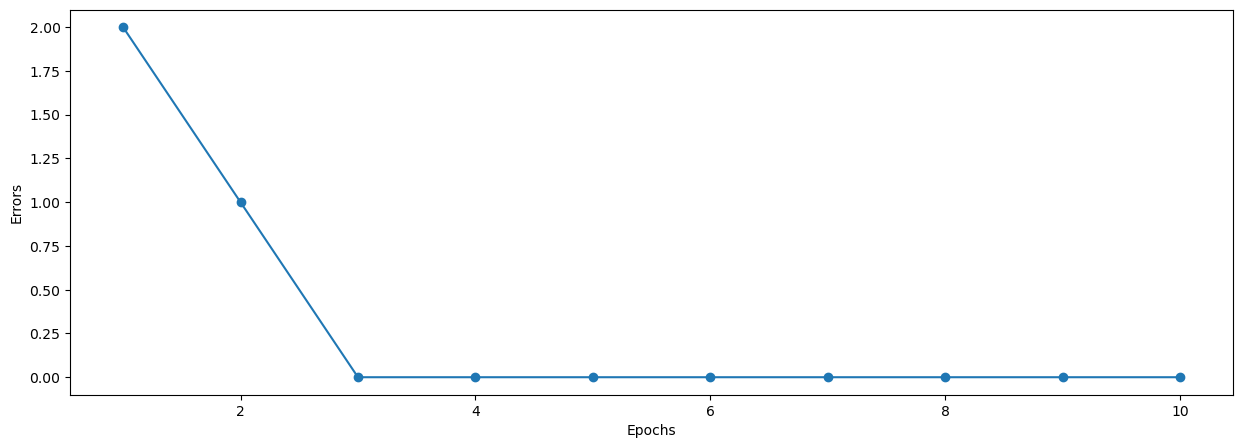

In [79]:
ppn = Perceptron(eta=0.001, n_iter=10, random_state=100)

ppn.fit(X, y)

plt.figure(figsize=(15, 5))
plt.subplot(1,1,1)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Errors')

plt.show()

### Perceptron Learning (Linearly Separable Dataset)

<img src="images/perceptron.gif" width="500">

### Let's inspect the decision-making boundary

In [80]:
import warnings
warnings.filterwarnings('ignore')
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))]) 
        
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
        
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

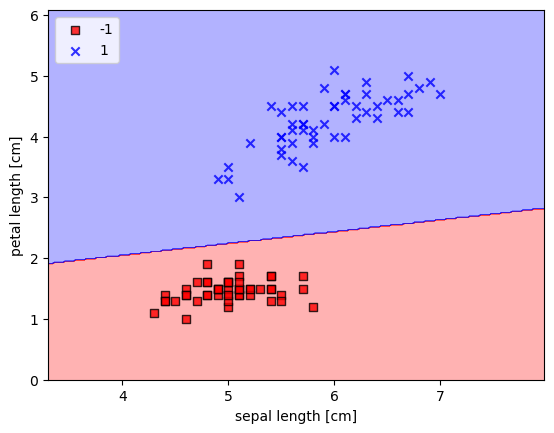

In [81]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

#x = np.array([3.5,1])
#plt.scatter(x[0], x[1])

plt.show()

### What happens on a non-linearly separable dataset?

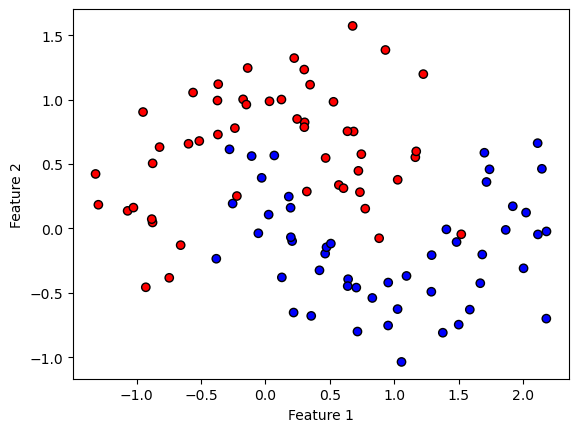

In [82]:
from sklearn.datasets import make_moons

X, y = make_moons(noise=0.3, random_state=0)
y = np.where(y==0, -1, 1)

# plot data
cmap = ListedColormap(['red', 'blue'])
colors = ('red', 'blue')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

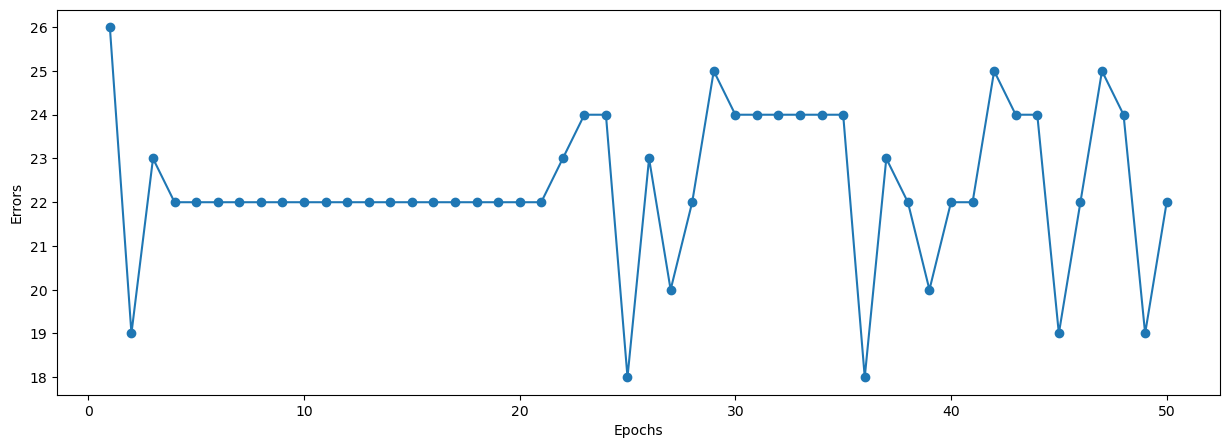

In [83]:
ppn = Perceptron(eta=0.001, n_iter=50)

ppn.fit(X, y)

plt.figure(figsize=(15, 5))
plt.subplot(1,1,1)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Errors')

plt.show()

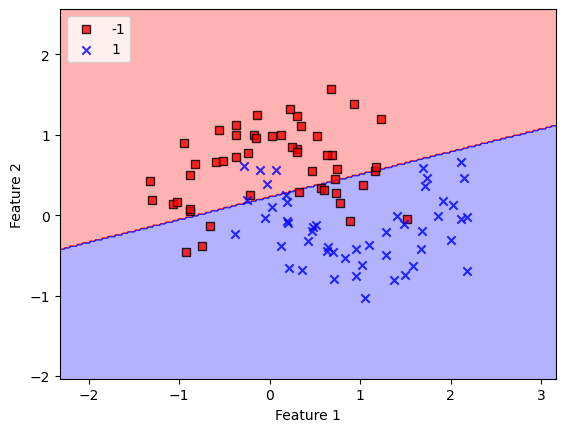

In [84]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')

plt.show()

### Perceptron Learning (non-Linearly Separable Dataset)

<img src="images/perceptron2.gif" width="500">

<br>
<br>

# Adaptive Linear Neurons (ADALINE)

ADALINE is an alternative learning algorithm for the McCulloch-Pitts neuron model.

- **Origins:** Proposed by Bernard Widrow and Ted Hoff in 1960.
- **Optimization Formulation:** Frames the learning task as a continuous optimization problem.
- **Robust Convergence:** Avoids the convergence issues of the standard Perceptron, even when training on non-linearly separable datasets.

### Key Difference from the Perceptron

Unlike Rosenblatt's Perceptron, ADALINE uses a **linear activation function** during the learning process:

$$\phi\left(\mathbf{w}^{T} \mathbf{x}\right) = \mathbf{w}^{T} \mathbf{x}$$

<img src="images/02_09.png" width="600">

- **Continuous Error Estimation:** During training, the true binary label is compared directly against the continuous output of the linear combination ($\mathbf{w}^{T} \mathbf{x}$).
- **Thresholding at Prediction:** The thresholding activation function (step function) is applied exclusively during the final prediction phase.

### ADALINE: Definition of the Objective Function

- An **objective function** maps the values of a parameter vector (in this case, $\mathbf{w}$) to a single real number representing the overall cost or error.

In ADALINE, the objective function $J(\mathbf{w})$ is defined as the Sum of Squared Errors (SSE) between the real labels and the model's continuous predictions:

$$J(\mathbf{w})=\frac{1}{2} \sum_{i}\left(y^{(i)}-\phi\left(\mathbf{w}^{T} \mathbf{x}^{(i)}\right)\right)^{2}$$

Since the linear activation function yields $\phi\left(\mathbf{w}^{T} \mathbf{x}^{(i)}\right) = \mathbf{w}^{T} \mathbf{x}^{(i)}$, the cost function simplifies to:

$$J(\mathbf{w})=\frac{1}{2} \sum_{i}\left(y^{(i)}-\mathbf{w}^{T} \mathbf{x}^{(i)}\right)^{2}$$

The factor of $\frac{1}{2}$ is introduced purely for convenience to simplify the math when taking the derivative.

Let's examine how this cost function behaves on the sample dataset:

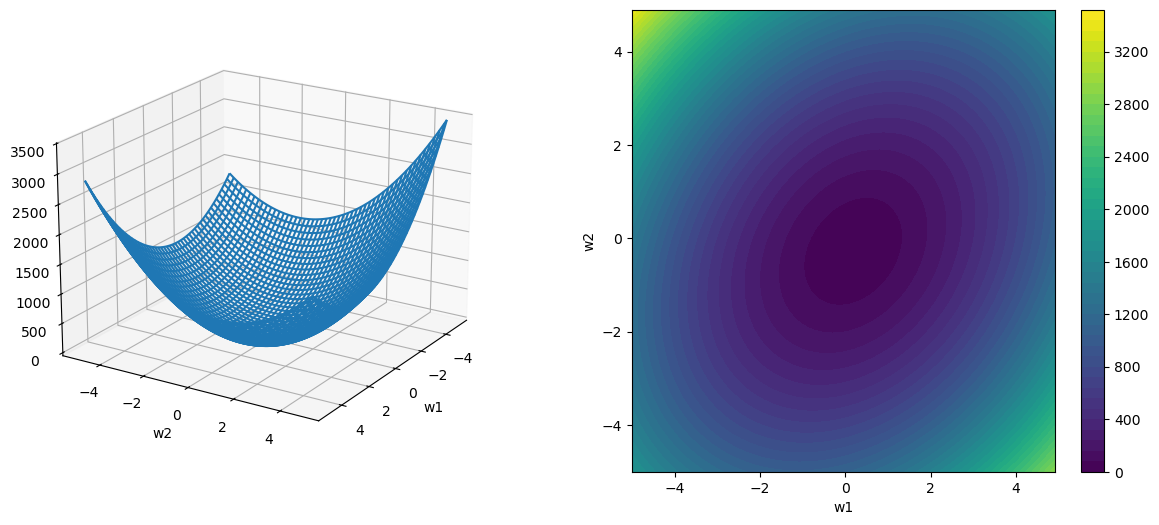

w ottimo: [np.float64(0.19999999999998153), np.float64(-0.3000000000000167)]


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np

X, y = make_moons(noise=0.3, random_state=0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

def J(w, X, y):
    return 0.5*np.sum(np.square(y - np.dot(X,w)))

w1_min, w1_max = -5, 5
w2_min, w2_max = -5, 5
resolution = 0.1

w1_lin = np.arange(w1_min, w1_max, resolution)
w2_lin = np.arange(w2_min, w2_max, resolution)
ww1, ww2 = np.meshgrid(w1_lin, w2_lin)

JJ = np.zeros_like(ww1.ravel())
for i in range(len(ww1.ravel())):
    curr_w = np.array([ww1.ravel()[i],ww2.ravel()[i]])
    JJ[i] = J(curr_w, X, y)
    
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(1,2,1, projection='3d')

JJ = JJ.reshape(ww1.shape)
ax.plot_wireframe(ww1, ww2, JJ)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('J')
ax.view_init(elev=20., azim=32)

ax = fig.add_subplot(1,2,2)
ctp = ax.contourf(ww1, ww2, JJ, levels=50)
fig.colorbar(ctp)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
plt.show()

ind = np.unravel_index(np.argmin(JJ, axis=None), JJ.shape)
print('w ottimo: ' + str([w1_lin[ind[1]], w2_lin[ind[0]]]))

- **Convexity & Differentiability:** The cost function $J(\mathbf{w})$ is strictly convex and differentiable, ensuring a single global minimum without local minima.
- The learning objective is to find the parameter vector $\mathbf{w}$ that minimizes $J(\mathbf{w})$.

**Two Main Approaches:**

1. **Analytical Solution:** Solving directly for $\mathbf{w}$ using closed-form linear algebra.
2. **Gradient Descent Optimization:** Iteratively updating $\mathbf{w}$ in the direction of steepest descent to reach the global minimum.

## Analytical Solution

The learning task can be framed as a system of linear equations containing one equation for each example in the dataset:

- Let $\mathbf{X} \in \mathbb{R}^{n \times d}$ be the design matrix whose $n$ rows correspond to the feature vectors (samples) of dimension $d$.
- Let $\mathbf{y} \in \mathbb{R}^{n \times 1}$ be the target vector containing labels in $\{-1, 1\}$.
- Let $\mathbf{w} \in \mathbb{R}^{d \times 1}$ be the weight vector.

We wish to solve:

$$\mathbf{y} = \mathbf{X}\mathbf{w}$$

- **Overdetermined System:** Since there are typically more equations than unknowns ($n > d$), an exact solution does not generally exist.
- **Ordinary Least Squares (OLS):** We can compute the optimal approximate weight vector $\mathbf{\hat{w}}$ by minimizing the squared error norm:

$$\mathbf{\hat{w}} = \underset{\mathbf{w}}{\operatorname{argmin}} \, \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^{2}$$

**Closed-Form Solution:**

$$\mathbf{\hat{w}} = \mathbf{X}^{\dagger}\mathbf{y}$$

where $\mathbf{X}^{\dagger}$ denotes the Moore-Penrose pseudoinverse:

$$\mathbf{X}^{\dagger} = \left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T}$$

### Step-by-Step Derivation of the OLS Closed-Form Solution

To find the weight vector $\mathbf{\hat{w}}$ that minimizes the sum of squared errors, we expand the cost function $J(\mathbf{w})$ defined as the squared $L_2$-norm of the residual vector:

$$J(\mathbf{w}) = \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^{2} = (\mathbf{y} - \mathbf{X}\mathbf{w})^{T} (\mathbf{y} - \mathbf{X}\mathbf{w})$$

**Step 1: Apply the Transpose Rule to the First Term**
Using the matrix property $(\mathbf{A} - \mathbf{B})^T = \mathbf{A}^T - \mathbf{B}^T$ and $(\mathbf{A}\mathbf{B})^T = \mathbf{B}^T \mathbf{A}^T$:

$$(\mathbf{y} - \mathbf{X}\mathbf{w})^{T} = \mathbf{y}^{T} - (\mathbf{X}\mathbf{w})^{T} = \mathbf{y}^{T} - \mathbf{w}^{T}\mathbf{X}^{T}$$

Substituting this back into $J(\mathbf{w})$ gives:

$$J(\mathbf{w}) = (\mathbf{y}^{T} - \mathbf{w}^{T}\mathbf{X}^{T}) (\mathbf{y} - \mathbf{X}\mathbf{w})$$

---

**Step 2: Distribute the Product**
Expanding the multiplication term-by-term:

$$J(\mathbf{w}) = \underbrace{\mathbf{y}^{T}\mathbf{y}}_{\text{Term 1}} - \underbrace{\mathbf{y}^{T}\mathbf{X}\mathbf{w}}_{\text{Term 2}} - \underbrace{\mathbf{w}^{T}\mathbf{X}^{T}\mathbf{y}}_{\text{Term 3}} + \underbrace{\mathbf{w}^{T}\mathbf{X}^{T}\mathbf{X}\mathbf{w}}_{\text{Term 4}}$$

---

**Step 3: Combine Equivalent Scalar Terms**
Notice the dimensions of Term 2:
- $\mathbf{y}^T$ is $(1 \times n)$
- $\mathbf{X}$ is $(n \times d)$
- $\mathbf{w}$ is $(d \times 1)$

Multiplying $(1 \times n) \times (n \times d) \times (d \times 1)$ results in a $(1 \times 1)$ **scalar**. 

Since the transpose of a scalar is equal to itself ($a = a^T$):

$$\mathbf{y}^{T}\mathbf{X}\mathbf{w} = (\mathbf{y}^{T}\mathbf{X}\mathbf{w})^{T} = \mathbf{w}^{T}\mathbf{X}^{T}\mathbf{y}$$

Thus, Terms 2 and 3 are identical and can be merged:

$$J(\mathbf{w}) = \mathbf{y}^{T}\mathbf{y} - 2\mathbf{w}^{T}\mathbf{X}^{T}\mathbf{y} + \mathbf{w}^{T}\mathbf{X}^{T}\mathbf{X}\mathbf{w}$$

---

**Step 4: Differentiate with Respect to $\mathbf{w}$**
Using standard matrix calculus identities:
1. $\frac{\partial}{\partial \mathbf{w}} (\mathbf{y}^{T}\mathbf{y}) = \mathbf{0}$ *(constant with respect to $\mathbf{w}$)*
2. $\frac{\partial}{\partial \mathbf{w}} (\mathbf{w}^{T}\mathbf{a}) = \mathbf{a} \implies \frac{\partial}{\partial \mathbf{w}} (-2\mathbf{w}^{T}\mathbf{X}^{T}\mathbf{y}) = -2\mathbf{X}^{T}\mathbf{y}$
3. $\frac{\partial}{\partial \mathbf{w}} (\mathbf{w}^{T}\mathbf{A}\mathbf{w}) = 2\mathbf{A}\mathbf{w} \implies \frac{\partial}{\partial \mathbf{w}} (\mathbf{w}^{T}\mathbf{X}^{T}\mathbf{X}\mathbf{w}) = 2\mathbf{X}^{T}\mathbf{X}\mathbf{w}$

Setting the gradient vector $\nabla_{\mathbf{w}} J(\mathbf{w})$ to $\mathbf{0}$:

$$\nabla_{\mathbf{w}} J(\mathbf{w}) = -2\mathbf{X}^{T}\mathbf{y} + 2\mathbf{X}^{T}\mathbf{X}\mathbf{w} = \mathbf{0}$$

---

**Step 5: Isolate $\mathbf{w}$**

$$2\mathbf{X}^{T}\mathbf{X}\mathbf{w} = 2\mathbf{X}^{T}\mathbf{y}$$

$$\mathbf{X}^{T}\mathbf{X}\mathbf{w} = \mathbf{X}^{T}\mathbf{y}$$

Multiplying both sides from the left by the inverse $(\mathbf{X}^{T}\mathbf{X})^{-1}$ (assuming $\mathbf{X}^{T}\mathbf{X}$ is full rank/invertible):

$$(\mathbf{X}^{T}\mathbf{X})^{-1}\mathbf{X}^{T}\mathbf{X}\mathbf{w} = (\mathbf{X}^{T}\mathbf{X})^{-1}\mathbf{X}^{T}\mathbf{y}$$

$$\mathbf{I}\mathbf{\hat{w}} = (\mathbf{X}^{T}\mathbf{X})^{-1}\mathbf{X}^{T}\mathbf{y}$$

$$\mathbf{\hat{w}} = \left(\mathbf{X}^{T}\mathbf{X}\right)^{-1} \mathbf{X}^{T}\mathbf{y} = \mathbf{X}^{\dagger}\mathbf{y}$$

## Optimization via Gradient Descent

- **Gradient Definition:** The gradient is a generalization of the standard derivative to multidimensional functions.
- **Vector of Partial Derivatives:** It is a vector containing the partial derivatives of the function with respect to each of its variables (dimensions):

$$\nabla J(\mathbf{w}) = \left[ \frac{\partial J}{\partial w_0}, \frac{\partial J}{\partial w_1}, \dots, \frac{\partial J}{\partial w_m} \right]^T$$

- **Direction of Steepest Ascent:** The gradient vector points in the direction of the maximum rate of increase of the function. Consequently, moving in the opposite direction ($-\nabla J(\mathbf{w})$) yields the direction of steepest descent toward the minimum.

<img src="images/02_10.png" width="600">
<img src="images/grad_2d.png" width="450">

- **Gradient Descent Update Rule:** We can minimize the cost function by adjusting the weight vector in the direction opposite to its gradient, $\nabla J(\mathbf{w})$:

$$\mathbf{w} := \mathbf{w} + \Delta \mathbf{w}$$

where the update vector $\Delta \mathbf{w}$ is defined as the negative gradient scaled by the learning rate $\eta$:

$$\Delta \mathbf{w} = -\eta \nabla J(\mathbf{w})$$

- **Partial Derivatives:** To compute the gradient of the cost function, we calculate the partial derivative with respect to each individual weight $w_j$:

$$\frac{\partial J}{\partial w_{j}} = -\sum_{i} \left(y^{(i)} - \phi\left(z^{(i)}\right)\right) x_{j}^{(i)}$$

- **Weight Update Rule:** The update for each weight $w_j$ is then expressed as:

$$\Delta w_{j} = -\eta \frac{\partial J}{\partial w_{j}} = \eta \sum_{i} \left(y^{(i)} - \phi\left(z^{(i)}\right)\right) x_{j}^{(i)}$$

- **Linear Activation:** Recall that for ADALINE, the activation function is simply the identity of the linear combination:

$$\phi\left(z^{(i)}\right) = \phi\left(\mathbf{w}^{T} \mathbf{x}^{(i)}\right) = \mathbf{w}^{T} \mathbf{x}^{(i)}$$

### Key Differences Between Perceptron and ADALINE Update Rules

- **Perceptron Update Rule (Online / Sample-by-Sample):**

$$w_{j} := w_{j} + \Delta w_{j}$$

where:

$$\Delta w_{j} = \eta\left(y^{(i)} - \phi\left(z^{(i)}\right)\right) x_{j}^{(i)}$$

The weights are updated incrementally after evaluating **each individual training sample** $i$, where $\phi\left(z^{(i)}\right) \in \{-1, 1\}$ is a non-linear step function.

- **ADALINE Update Rule (Batch Gradient Descent):**

$$w_{j} := w_{j} + \Delta w_{j}$$

where:

$$\Delta w_{j} = \eta \sum_{i}\left(y^{(i)} - \phi\left(z^{(i)}\right)\right) x_{j}^{(i)}$$

The weight update is calculated by accumulating the errors across **the entire training dataset** (batch processing) before making a single update step per epoch, using a linear activation function $\phi\left(z^{(i)}\right) = \mathbf{w}^{T}\mathbf{x}^{(i)}$.

<br>
<br>

## ADALINE in Python

In [85]:
class Adaline(object):
    
    def __init__(self, eta=0.01, n_iter=50, random_state=123):
        self.eta = eta
        self.n_iter = n_iter
        np.random.seed(random_state)

    def fit(self, X, y, method='GD'):
        
        if method=='GD':
        
            self.w_ = np.random.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
            self.cost_ = []

            for i in range(self.n_iter):
                self.cost_.append(self._update_weights(X, y))
        else:

            X = np.hstack([np.ones([X.shape[0],1]), X])
            self.w_ = np.linalg.pinv(X) @ y
            
        return self

    def integrate(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def _update_weights(self, X, y):
        """Apply Adaline learning rule to update the weights"""
        output = self.integrate(X)
        errors = (y - output)
        self.w_[1:] += self.eta * X.T.dot(errors)
        self.w_[0] += self.eta * errors.sum()
        cost = (errors**2).sum() / 2.0
        return cost

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.integrate(X) >= 0.0, 1, -1)

### Learning ADALINE via Gradient Descent

- How does the value of the objective function change across successive iterations?
- What is the exact effect of the learning rate parameter $\eta$ on convergence behavior?


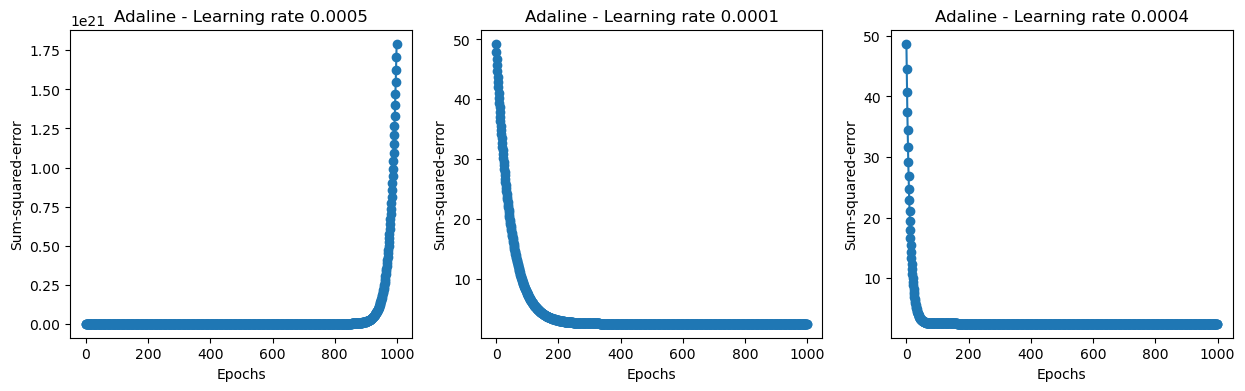

In [86]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

X = np.copy(X_iris)
y = np.copy(y_iris)

niter = 1000

ada1 = Adaline(n_iter=niter, eta=.0005).fit(X, y)
ax[0].plot(range(len(ada1.cost_)), ada1.cost_, marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Sum-squared-error')
ax[0].set_title('Adaline - Learning rate 0.0005')

ada2 = Adaline(n_iter=niter, eta=0.0001).fit(X, y)
ax[1].plot(range(len(ada2.cost_)), ada2.cost_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Sum-squared-error')
ax[1].set_title('Adaline - Learning rate 0.0001')

ada3 = Adaline(n_iter=niter, eta=0.0004, random_state=0).fit(X, y)
ax[2].plot(range(len(ada3.cost_)), ada3.cost_, marker='o')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Sum-squared-error')
ax[2].set_title('Adaline - Learning rate 0.0004')

plt.show()

<img src="images/02_12.png" width="600">

### Comparison Gradient Descent vs. Closed Shape

In [87]:
ada3.w_

array([-0.258, -0.372,  0.803])

In [88]:
ada4 = Adaline().fit(X, y, method='CF')
ada4.w_

array([-0.705, -0.275,  0.772])

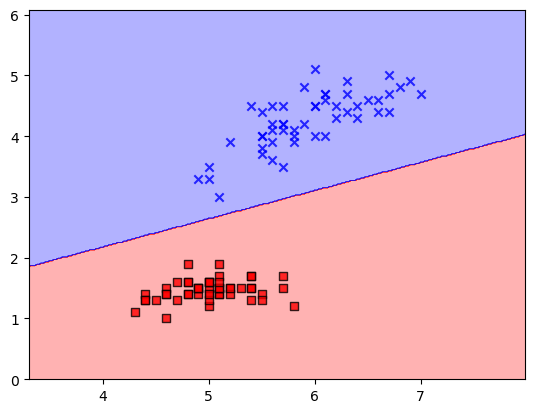

In [89]:
plot_decision_regions(X, y, classifier=ada3)

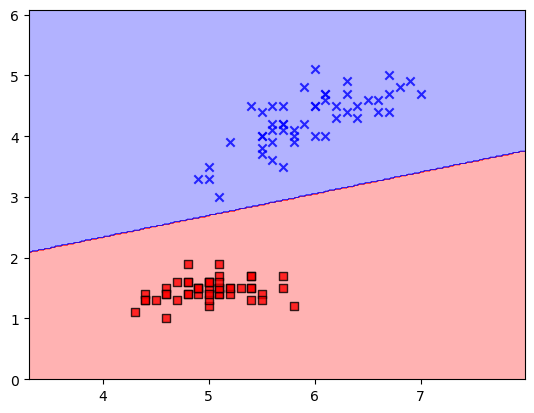

In [90]:
plot_decision_regions(X, y, classifier=ada4)

<br>
<br>

## Best Practices: Feature Standardization

- Many machine learning algorithms (including Gradient Descent) benefit significantly from **feature scaling** techniques.
- One of the most widely used feature scaling methods is **standardization**.
- Each feature in the dataset is transformed so that it has a mean of $0$ and a standard deviation of $1$.

Let $\boldsymbol{x}_j$ represent the $j$-th feature column of the dataset. Standardization is defined as:

$$\boldsymbol{x}_{j}^{\prime} = \frac{\boldsymbol{x}_{j} - \mu_{j}}{\sigma_{j}}$$

where $\mu_j$ is the mean and $\sigma_j$ is the standard deviation of feature $j$.

A key advantage of standardization is that Gradient Descent typically requires far fewer iterations to converge to the minimum of the objective function.

<img src="images/02_13.png" width="600">

In [57]:
# standardize features

X = np.copy(X_iris)
y = np.copy(y_iris)

X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

#...alternativamente ed in modo equivalente:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

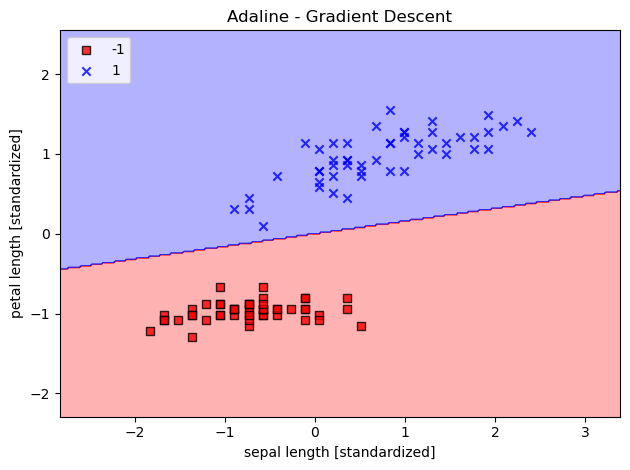

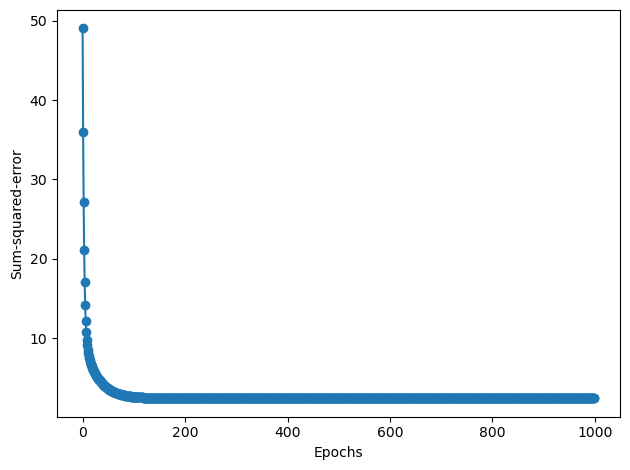

In [58]:
ada_gd = Adaline(n_iter=1000, eta=.001).fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.plot(range(len(ada_gd.cost_)), ada_gd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')

plt.tight_layout()
plt.show()

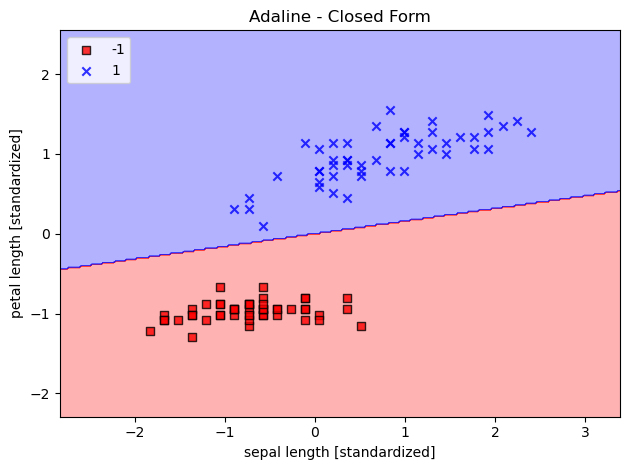

In [59]:
ada_closed = Adaline().fit(X_std, y, method='CF')

plot_decision_regions(X_std, y, classifier=ada_closed)
plt.title('Adaline - Closed Form')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [60]:
ada_gd.w_

array([ 0.   , -0.176,  1.113])

In [61]:
ada_closed.w_

array([ 0.   , -0.176,  1.113])

<br>
<br>

## Large-Scale Learning: Stochastic Gradient Descent (SGD)

Recall the weight update rule for ADALINE using standard Batch Gradient Descent:

$$\mathbf{w} := \mathbf{w} + \Delta \mathbf{w}$$

where:

$$\Delta \mathbf{w} = \eta \sum_{i=1}^{n} \left(y^{(i)} - \mathbf{w}^{T}\mathbf{x}^{(i)}\right) \mathbf{x}^{(i)}$$

- **Computational Bottleneck:** Each weight update requires evaluating the entire training dataset. This becomes computationally prohibitive for massive datasets containing millions of samples.
- **Analytical Limitations:** A similar computational barrier exists for the analytical solution (Ordinary Least Squares), which requires storing and inverting a massive design matrix:

$$\mathbf{\hat{w}} = \mathbf{X}^{\dagger}\mathbf{y}$$

where:

$$\mathbf{X}^{\dagger} = \left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T}$$

---

### Mini-Batch & Stochastic Gradient Descent

To scale learning to large datasets, updates can be computed on a smaller, randomly sampled subset of the data (a **mini-batch**):

- Let $\mathbf{X}_{\text{MB}} \in \mathbb{R}^{m \times d}$ represent the mini-batch matrix formed by randomly sampling $m$ rows ($m < n$) from the original dataset $\mathbf{X} \in \mathbb{R}^{n \times d}$.
- Let $\mathbf{y}_{\text{MB}} \in \mathbb{R}^{m}$ be the corresponding target vector.

The weight update rule for Mini-Batch Gradient Descent is given by:

$$\mathbf{w} := \mathbf{w} + \Delta \mathbf{w}$$

where:

$$\Delta \mathbf{w} = \eta \sum_{i=1}^{m} \left(y_{\text{MB}}^{(i)} - \mathbf{w}^{T}\mathbf{x}_{\text{MB}}^{(i)}\right) \mathbf{x}_{\text{MB}}^{(i)}$$

#### Extreme Case ($m = 1$): True Stochastic Gradient Descent

When the mini-batch size is set to $1$, weights are updated incrementally after evaluating each individual sample $i$:

$$\Delta \mathbf{w} = \eta \left(y^{(i)} - \mathbf{w}^{T}\mathbf{x}^{(i)}\right) \mathbf{x}^{(i)}$$

This formulation matches the structural form of the Perceptron update rule, with the primary distinction being ADALINE's use of a continuous linear activation function rather than a discrete step function:

$$\Delta \mathbf{w} = \eta \left(y^{(i)} - \phi\left(\mathbf{w}^{T}\mathbf{x}^{(i)}\right)\right) \mathbf{x}^{(i)}$$

In [62]:
class AdalineSGD(object):
    
    def __init__(self, eta=0.01, n_iter=10, batch_size=32, method='SGD',random_state=123):
        self.eta = eta
        self.n_iter = n_iter
        np.random.seed(random_state)
        self.batch_size = batch_size
        self.method = method
        
    def fit(self, X, y):
       
        self.w_ = np.random.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []
        
        if self.method == 'SGD':
            for i in range(self.n_iter):
                X, y = self._shuffle(X, y)
                cost = []

                for j in range(X.shape[0] // self.batch_size):
                    start = j*self.batch_size
                    end = j*self.batch_size+self.batch_size
                    X_mb = X[start:end,:]
                    y_mb = y[start:end]
                    cost.append(self._update_weights(X_mb, y_mb))

                avg_cost = np.mean(cost)
                self.cost_.append(avg_cost)
        else:

            X = np.hstack([np.ones([X.shape[0],1]), X])
            self.w_ = np.linalg.pinv(X) @ y
        
        return self


    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = np.random.permutation(len(y))
        return X[r], y[r]
        
    def _update_weights(self, X, y):
        """Apply Adaline learning rule to update the weights"""
        output = self.integrate(X)
        errors = (y - output)
        self.w_[1:] += self.eta * X.T.dot(errors)
        self.w_[0] += self.eta * errors.sum()
        cost = (errors**2).sum() / 2.0
        return cost
    
    def integrate(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.integrate(X) >= 0.0, 1, -1)

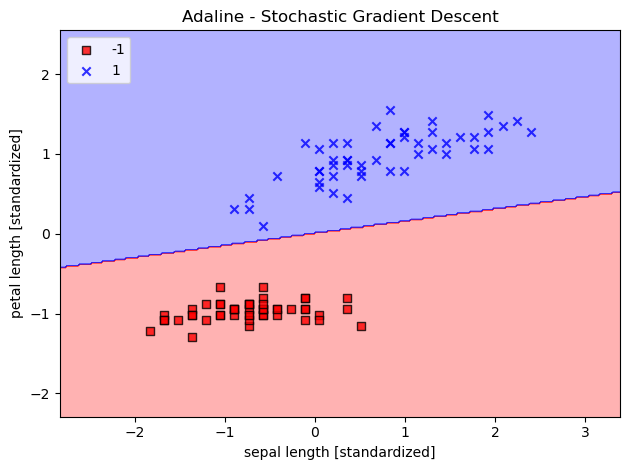

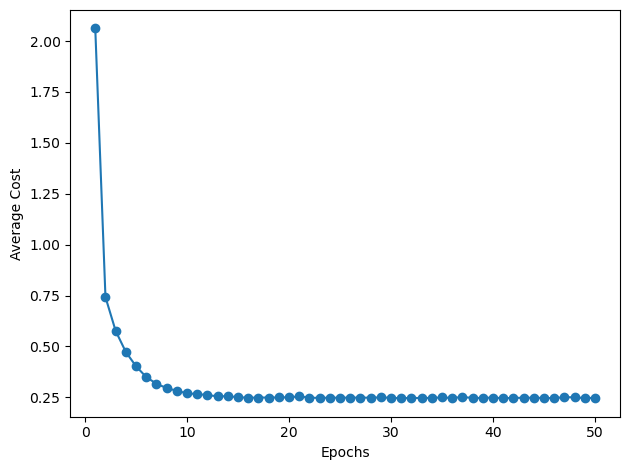

array([-0.008, -0.17 ,  1.117])

In [63]:
ada_sgd = AdalineSGD(n_iter=50, batch_size=10, eta=0.01)
ada_sgd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd.cost_) + 1), ada_sgd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average Cost')

plt.tight_layout()
plt.show()

ada_sgd.w_

### ADALINE on a non-linearly separable dataset

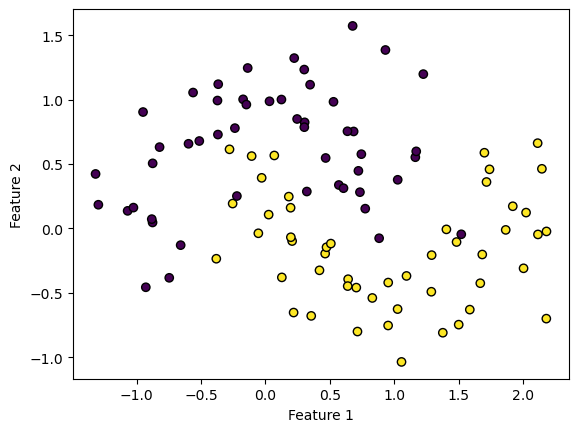

In [64]:
from sklearn.datasets import make_moons

X, y = make_moons(noise=0.3, random_state=0)
y = np.where(y==0, -1, 1)

X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

# plot data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

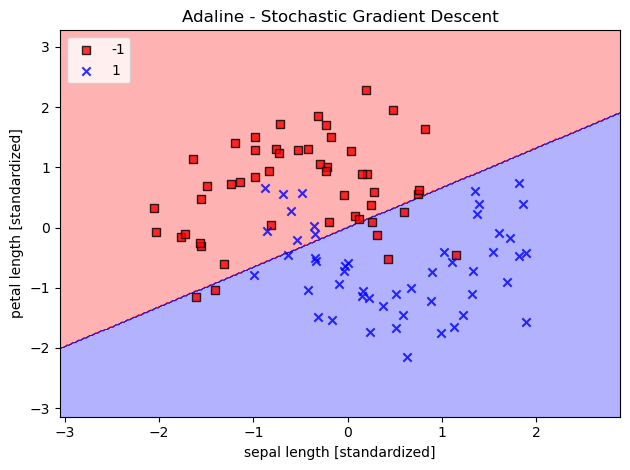

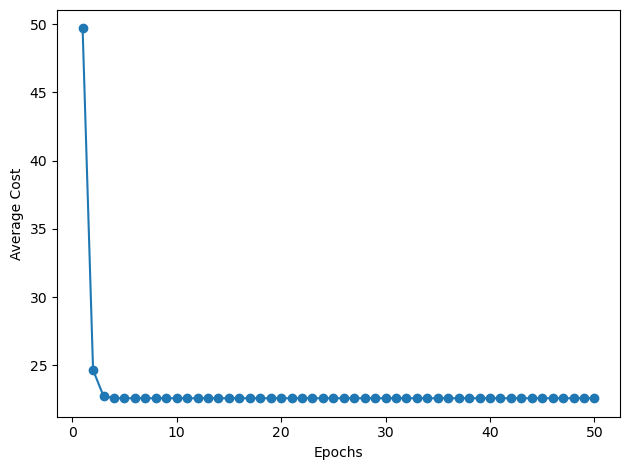

In [65]:
ada_sgd = AdalineSGD(n_iter=50, batch_size=100, eta=0.01)#, method='CF')

ada_sgd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd.cost_) + 1), ada_sgd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average Cost')

plt.tight_layout()
plt.show()

### Adaline Learning (non-Linearly Separable Dataset)

<img src="images/adaline.gif" width="500">

## Logistic Regression

- Like the Perceptron and ADALINE, **Logistic Regression** is a linear model used for binary classification.
- Unlike these deterministic models, Logistic Regression is a **probabilistic model**, directly modeling the conditional probability of an input belonging to a specific class.

### The Odds Ratio and the Logit Function

We define the **odds** in favor of the positive event, where $p = P(y=1 \mid \mathbf{x})$, as the ratio of the probability of the event occurring to the probability of it not occurring:

$$\text{odds}(p) = \frac{p}{1 - p}$$

Taking the natural logarithm of the odds yields the **logit function**:

$$\operatorname{logit}(p) = \ln \left(\frac{p}{1 - p}\right)$$

The logit function maps input probabilities bounded in the interval $(0, 1)$ onto the entire real line $(-\infty, +\infty)$:

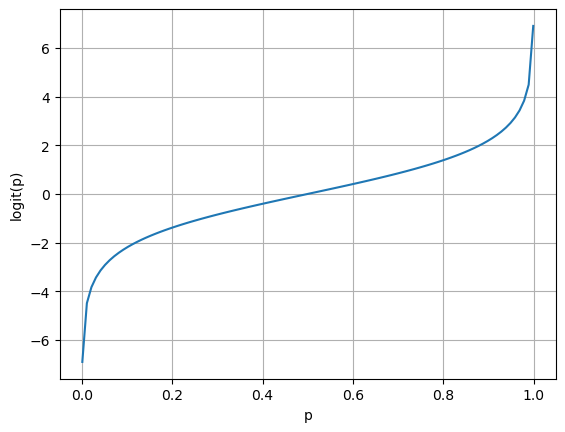

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def logit(p):
    return np.log(p / (1-p))

p = np.linspace(0.001, 0.999, 100)
lp = logit(p)

plt.plot(p,lp)
plt.grid()
plt.xlabel('p')
plt.ylabel('logit(p)')
plt.show()

When applying a linear framework to probabilistic classification, we encounter a fundamental domain discrepancy:
- The linear combination of features and weights $\mathbf{w}^{T} \mathbf{x}$ can take on any real value, operating on the unconstrained range $(-\infty, +\infty)$.
- The estimated probability $P(y=1 \mid \mathbf{x})$, by definition, must strictly remain within the bounded interval $[0, 1]$.

To bridge this gap, we relate the linear combination $\mathbf{w}^{T} \mathbf{x}$ to $P(y=1 \mid \mathbf{x})$ by equating it to the **log-odds** (the $\operatorname{logit}$ function):

$$\operatorname{logit}(P(y=1 \mid \mathbf{x})) = \ln\left(\frac{P(y=1 \mid \mathbf{x})}{1 - P(y=1 \mid \mathbf{x})}\right) = \mathbf{w}^{T} \mathbf{x}$$

However, our ultimate objective is to compute the conditional probability $P(y=1 \mid \mathbf{x})$ directly for a given input vector $\mathbf{x}$. To isolate $P(y=1 \mid \mathbf{x})$, we must invert the $\operatorname{logit}$ function.

The mathematical inverse of the $\operatorname{logit}$ function is precisely the **logistic function** (commonly called the **sigmoid function**), denoted as $\phi(z)$:

$$\phi(z) = \operatorname{logit}^{-1}(z) = \frac{1}{1 + e^{-z}}$$

By substituting the continuous linear net input $z = \mathbf{w}^{T} \mathbf{x}$ into the sigmoid function, we arrive at the primary formulation for Logistic Regression:

$$P(y=1 \mid \mathbf{x}) = \phi(\mathbf{w}^{T} \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^{T} \mathbf{x}}}$$

Thus, the sigmoid acts as a "squashing function," mapping any real-valued input $z \in (-\infty, +\infty)$ into a valid probability output within the range $(0, 1)$.

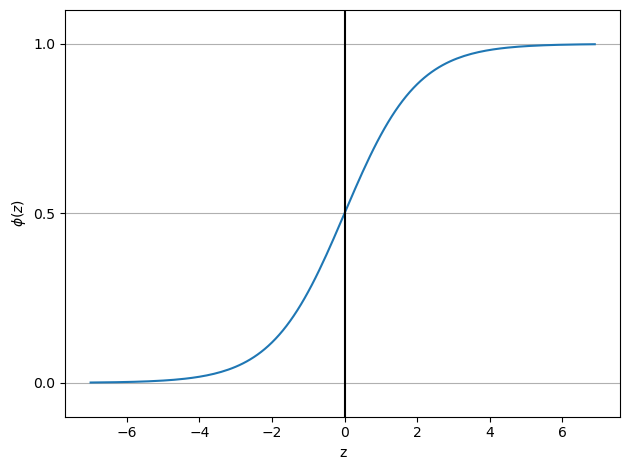

In [67]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
phi_z = sigmoid(z)

plt.plot(z, phi_z)
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel('$\phi (z)$')

# y axis ticks and gridline
plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

### Differences with ADALINE?

<img src="images/03_03.png" width="600">

### Logistic Regression Learning

As with ADALINE, we define an objective function $L(\mathbf{w})$:

$$L(\mathbf{w})=P(\mathbf{y} \mid \mathbf{X} ; \mathbf{w})=\prod_{i=1}^{n} P\left(y^{(i)} \mid \mathbf{x}^{(i)} ; \mathbf{w}\right)=\prod_{i=1}^{n}\left(\phi\left(z^{(i)}\right)\right)^{y^{(i)}}\left(1-\phi\left(z^{(i)}\right)\right)^{1-y^{(i)}}$$

The objective function $L(\mathbf{w})=P(\mathbf{y} \mid \mathbf{X} ; \mathbf{w})$ represents the joint probability of predicting the correct class labels given the feature matrix and the weight vector.

- This quantity is known as the model's **likelihood**.
- Our goal is to **maximize** this likelihood function.
- Expressing $P(\mathbf{y} \mid \mathbf{X} ; \mathbf{w})$ as a product $\prod_{i=1}^{n} P\left(y^{(i)} \mid \mathbf{x}^{(i)} ; \mathbf{w}\right)$ assumes conditional independence among individual dataset examples.
- The formulation $\left(\phi\left(z^{(i)}\right)\right)^{y^{(i)}}\left(1-\phi\left(z^{(i)}\right)\right)^{1-y^{(i)}}$ assumes that the probability of classifying the $i$-th sample as class $1$ is governed by a **Bernoulli distribution**:

$$P\left(y^{(i)} \mid \mathbf{x}^{(i)} ; \mathbf{w}\right) \sim \operatorname{Bern}(p) = p^{y^{(i)}}(1-p)^{1-y^{(i)}} \quad \text{for } y^{(i)} \in \{0, 1\}$$

In practice, we minimize the negative logarithm of the likelihood function $L(\mathbf{w})$, known as the **Binary Cross-Entropy** loss function $J(\mathbf{w})$:

$$J(\mathbf{w}) = -\sum_{i=1}^{n} \left[ y^{(i)} \ln \left(\phi\left(z^{(i)}\right)\right) + \left(1 - y^{(i)}\right) \ln \left(1 - \phi\left(z^{(i)}\right)\right) \right]$$

What does this objective function reveal about the model's penalty structure?

- Consider the cost evaluated for a single training example:

$$J(\phi(z), y ; \mathbf{w}) = -y \ln(\phi(z)) - (1 - y) \ln(1 - \phi(z))$$

Conditioning on the target label $y \in \{0, 1\}$, the single-example cost simplifies to:

$$J(\phi(z), y ; \mathbf{w}) = \begin{cases} 
-\ln(\phi(z)) & \text{if } y = 1 \\ 
-\ln(1 - \phi(z)) & \text{if } y = 0 
\end{cases}$$

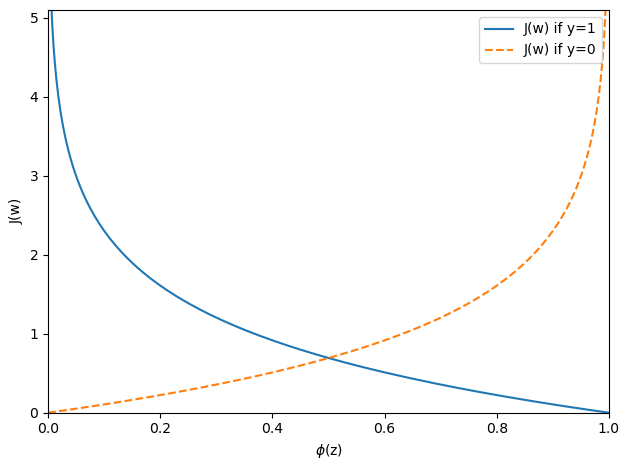

In [68]:
def cost_1(z):
    return - np.log(sigmoid(z))

def cost_0(z):
    return - np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
phi_z = sigmoid(z)

c1 = [cost_1(x) for x in z]
plt.plot(phi_z, c1, label='J(w) if y=1')

c0 = [cost_0(x) for x in z]
plt.plot(phi_z, c0, linestyle='--', label='J(w) if y=0')

plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel('$\phi$(z)')
plt.ylabel('J(w)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

#### Let's inspect the objective function:

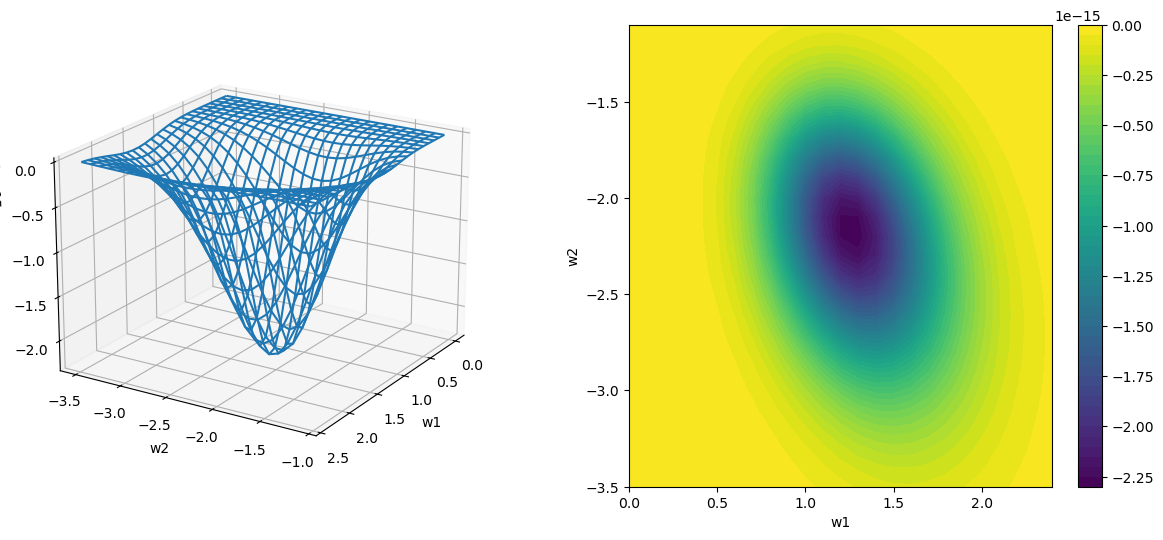

optimal w: [np.float64(1.3), np.float64(-2.199999999999999)]


In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

X, y = make_moons(noise=0.3, random_state=0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

#negative Likelihood
def J(w, X, y):
    return -np.prod(np.power(sigmoid(np.dot(X,w)),y) * np.power(1-sigmoid(np.dot(X,w)),(1-y)))

#For Negative Likelihood
w1_min, w1_max = 0, 2.5
w2_min, w2_max = -3.5, -1

resolution = 0.1

w1_lin = np.arange(w1_min, w1_max, resolution)
w2_lin = np.arange(w2_min, w2_max, resolution)
ww1, ww2 = np.meshgrid(w1_lin, w2_lin)

JJ = np.zeros_like(ww1.ravel())
for i in range(len(ww1.ravel())):
    curr_w = np.array([ww1.ravel()[i],ww2.ravel()[i]])
    JJ[i] = J(curr_w, X, y)
    
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(1,2,1, projection='3d')

JJ = JJ.reshape(ww1.shape)
ax.plot_wireframe(ww1, ww2, JJ)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('J')
ax.view_init(elev=20., azim=32)

ax = fig.add_subplot(1,2,2)
ctp = ax.contourf(ww1, ww2, JJ, levels=50)
fig.colorbar(ctp)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
plt.show()

ind = np.unravel_index(np.argmin(JJ, axis=None), JJ.shape)
print('optimal w: ' + str([w1_lin[ind[1]], w2_lin[ind[0]]]))

- Once again, we can optimize the cost function using the **Gradient Descent** algorithm.
- To do so, we compute the partial derivatives of the cost function with respect to the $j$-th weight $w_j$.

Evaluating these derivatives yields:

$$\frac{\partial J}{\partial w_{j}} = -\sum_{i=1}^{n} \left(y^{(i)} - \phi\left(z^{(i)}\right)\right) x_{j}^{(i)}$$

The weight update rule for Gradient Descent is then defined as follows:

$$w_{j} := w_{j} + \Delta w_{j}$$

where:

$$\Delta w_{j} = -\eta \frac{\partial J}{\partial w_{j}} = \eta \sum_{i=1}^{n} \left(y^{(i)} - \phi\left(z^{(i)}\right)\right) x_{j}^{(i)}$$

In vector form:

$$\mathbf{w}:=\mathbf{w}+\Delta \mathbf{w}, \quad \Delta \mathbf{w}=-\eta \nabla J(\mathbf{w})$$

#### Differences with ADALINE?

- ADALINE Update Rule:

$$w_{j}:=w_{j}+\Delta w_{j}$$

with:

$$\Delta w_{j}=\eta \sum_{i}\left(y^{(i)}-z^{(i)}\right) x_{j}^{(i)}$$

## Logistic Regression in Python

In [70]:
class LogisticRegressionGD(object):
    
    def __init__(self, eta=0.05, n_iter=100, random_state=123):
        self.eta = eta
        self.n_iter = n_iter
        np.random.seed(random_state)

    def fit(self, X, y):
        
        self.w_ = np.random.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            output = self.predict_prob(X)
            errors = (y - output)
            self.update_weigths(errors)
            
            cost = -y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))
            self.cost_.append(cost)
        return self
    
    def update_weigths(self, errors):
        self.w_[1:] += self.eta * X.T.dot(errors)
        self.w_[0] += self.eta * errors.sum()
        
    def integrate(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))
    
    def predict_prob(self, X):
        """Return class probability"""
        return self.activation(self.integrate(X))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.predict_prob(X) >= 0.5, 1, 0)

### Logistic Regression on the Iris dataset

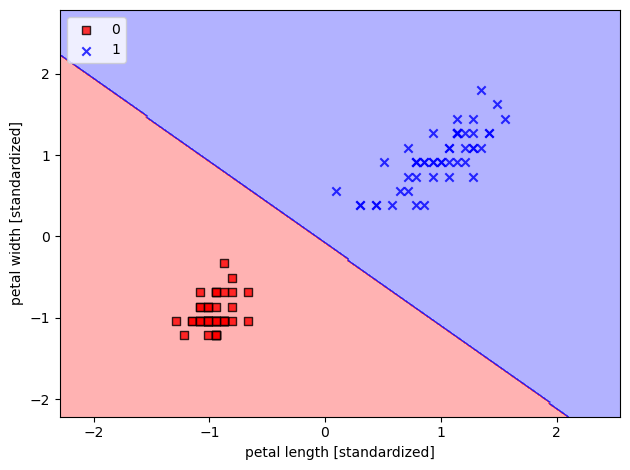

In [71]:
# select setosa and versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)
# extract petal length and petal width
X = df.iloc[0:100, [2, 3]].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

lrgd = LogisticRegressionGD(eta=0.05, n_iter=10, random_state=1)
lrgd.fit(X, y)

plot_decision_regions(X=X, y=y, classifier=lrgd)

plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### Predicting the probability of belonging to a class

- We use the predict_prob method to get the probability of an example belonging to the class $1$

In [72]:
ind = 55
xi = X[ind,:]
yi = y[ind]

xi_prob = lrgd.predict_prob(xi)

print("The data point belongs to class 1 with probability: " + str(xi_prob))
print("The data point belongs to class 0 with probability: " + str(1-xi_prob))
print("Correct class: " + str(yi))

The data point belongs to class 1 with probability: 0.9976495254883531
The data point belongs to class 0 with probability: 0.0023504745116469383
Correct class: 1


### Logistic regression on a non-linearly separable dataset

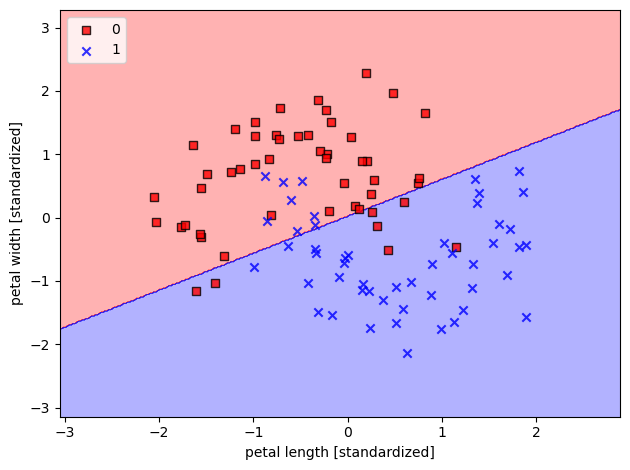

In [73]:
X, y = make_moons(noise=0.3, random_state=0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

lrgd = LogisticRegressionGD(eta=0.05, n_iter=100, random_state=1)
lrgd.fit(X, y)

plot_decision_regions(X=X, y=y, classifier=lrgd)

plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### Predicting the probability of belonging to a class

- We use the predict_prob method to get the probability of an example belonging to the class $1$

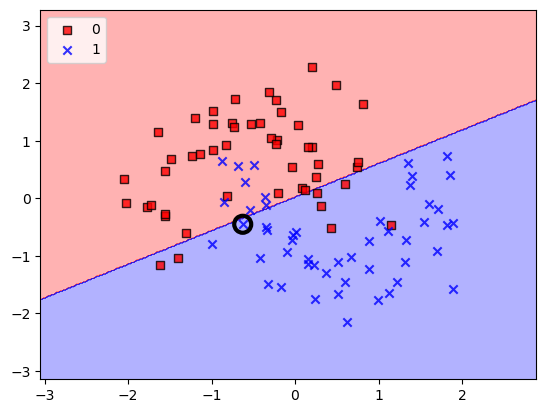

The data point belongs to class 1 with probability: 0.5571744991712041
The data point belongs to class 0 with probability: 0.4428255008287959
Correct class: 1


In [74]:
ind = 3 #1,2,3...

xi = X[ind,:]
yi = y[ind]

xi_prob = lrgd.predict_prob(xi)

plot_decision_regions(X=X, y=y, classifier=lrgd)
plt.scatter(xi[0], xi[1], color="none", edgecolor="black", s=150, linewidths=3)
plt.legend(loc='upper left')
plt.show()

print("The data point belongs to class 1 with probability: " + str(xi_prob))
print("The data point belongs to class 0 with probability: " + str(1-xi_prob))
print("Correct class: " + str(yi))

### Logistic Regression in scikit-learn

- **scikit-learn:** A popular Python library for machine learning algorithms.
- Provides an extensive collection of data processing and machine learning tools.
- Built on top of core scientific stack libraries including NumPy, SciPy, pandas, and Matplotlib.

We can implement Logistic Regression in Python using the `LogisticRegression` class:

By default, `scikit-learn` implements a **regularized** version of Logistic Regression. In this formulation, the minimized objective function $J_{\text{reg}}(\mathbf{w})$ is typically expressed as (note that different regularization types are supported):

$$J_{\text{reg}}(\mathbf{w}) = J(\mathbf{w}) + \frac{1}{C}\|\mathbf{w}\|^2$$

Minimizing this objective function forces the optimizer (Gradient Descent or other solvers) to find a parameter configuration that minimizes the negative log-likelihood while keeping the norm of the weight vector small (thus penalizing extreme values of $\mathbf{w}$).

This technique is known as **regularization** and enables models to **generalize** better—improving their ability to accurately classify previously unseen data.

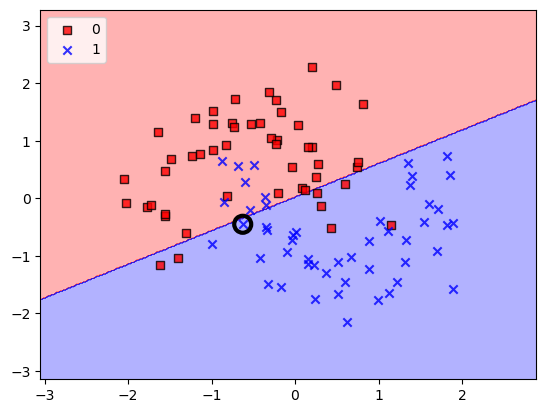

The data point belongs to class 1 with probability: 0.557368702120247
The data point belongs to class 0 with probability: 0.44263129787975297
Correct class: 1


In [75]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1000.0, random_state=1, solver='lbfgs')
lr.fit(X, y)

xi = X[ind,:].reshape(1,-1)
yi = y[ind]

xi_prob = lr.predict_proba(xi)

plot_decision_regions(X=X, y=y, classifier=lrgd)
plt.scatter(xi[:,0], xi[:,1], color="none", edgecolor="black", s=150, linewidths=3)
plt.legend(loc='upper left')
plt.show()

print("The data point belongs to class 1 with probability: " + str(xi_prob[0,1]))
print("The data point belongs to class 0 with probability: " + str(xi_prob[0,0]))
print("Correct class: " + str(yi))